load library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

load Dataset

In [7]:
data = pd.read_csv('../dataset/cars.csv')

01 Understand Dataset

In [8]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


02 shape of data

In [9]:
data.shape

(301, 9)

03 Data Types

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


04 Missing Values

In [11]:
data.isnull()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
296,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False
298,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False


In [13]:
data.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

5. Check Duplicate value.

In [14]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
296    False
297    False
298    False
299    False
300    False
Length: 301, dtype: bool

In [15]:
data.duplicated().sum()

np.int64(2)

6. Statistical Summary

In [16]:
print(data.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [18]:
print(data.describe(include="object"))

       Car_Name Fuel_Type Seller_Type Transmission
count       301       301         301          301
unique       98         3           2            2
top        city    Petrol      Dealer       Manual
freq         26       239         195          261


7. Unique Values

In [20]:
print(data.nunique())

Car_Name          98
Year              16
Selling_Price    156
Present_Price    147
Kms_Driven       206
Fuel_Type          3
Seller_Type        2
Transmission       2
Owner              3
dtype: int64


In [22]:
print(data["Car_Name"].unique())

['ritz' 'sx4' 'ciaz' 'wagon r' 'swift' 'vitara brezza' 's cross'
 'alto 800' 'ertiga' 'dzire' 'alto k10' 'ignis' '800' 'baleno' 'omni'
 'fortuner' 'innova' 'corolla altis' 'etios cross' 'etios g' 'etios liva'
 'corolla' 'etios gd' 'camry' 'land cruiser' 'Royal Enfield Thunder 500'
 'UM Renegade Mojave' 'KTM RC200' 'Bajaj Dominar 400'
 'Royal Enfield Classic 350' 'KTM RC390' 'Hyosung GT250R'
 'Royal Enfield Thunder 350' 'KTM 390 Duke ' 'Mahindra Mojo XT300'
 'Bajaj Pulsar RS200' 'Royal Enfield Bullet 350'
 'Royal Enfield Classic 500' 'Bajaj Avenger 220' 'Bajaj Avenger 150'
 'Honda CB Hornet 160R' 'Yamaha FZ S V 2.0' 'Yamaha FZ 16'
 'TVS Apache RTR 160' 'Bajaj Pulsar 150' 'Honda CBR 150' 'Hero Extreme'
 'Bajaj Avenger 220 dtsi' 'Bajaj Avenger 150 street' 'Yamaha FZ  v 2.0'
 'Bajaj Pulsar  NS 200' 'Bajaj Pulsar 220 F' 'TVS Apache RTR 180'
 'Hero Passion X pro' 'Bajaj Pulsar NS 200' 'Yamaha Fazer '
 'Honda Activa 4G' 'TVS Sport ' 'Honda Dream Yuga '
 'Bajaj Avenger Street 220' 'Hero Splend

In [23]:
print(data["Car_Name"].value_counts())

Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64


8. Outlier Detection

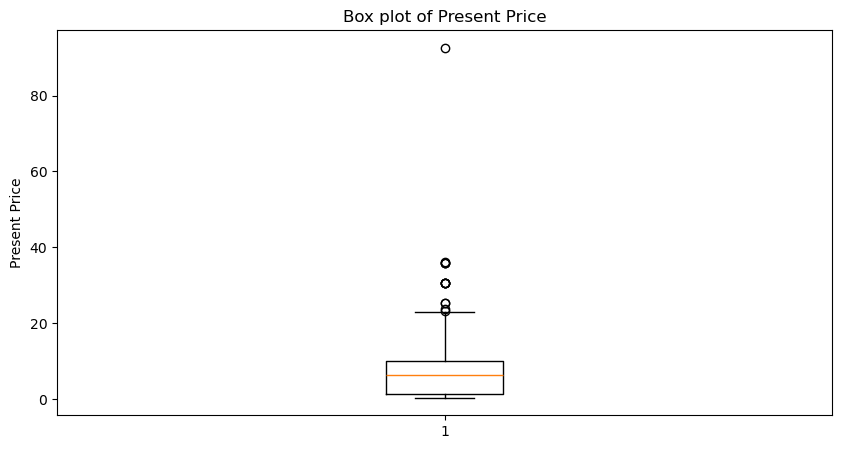

In [24]:
# Box Plot
figure = plt.figure(figsize=(10, 5))

plt.boxplot(data["Present_Price"])

plt.title("Box plot of Present Price")
plt.ylabel("Present Price")
plt.show()

In [26]:
# IQR
Q1 = data["Present_Price"].quantile(0.25)
Q3 = data["Present_Price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[
    (data["Present_Price"] < lower) |
    (data["Present_Price"] > upper)
]

print(outliers)

        Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
50      fortuner  2012          14.90          30.61      104707    Diesel   
51      fortuner  2015          23.00          30.61       40000    Diesel   
53      fortuner  2013          16.00          30.61      135000    Diesel   
59      fortuner  2014          19.99          35.96       41000    Diesel   
62      fortuner  2014          18.75          35.96       78000    Diesel   
63      fortuner  2015          23.50          35.96       47000    Diesel   
64      fortuner  2017          33.00          36.23        6000    Diesel   
66        innova  2017          19.75          23.15       11000    Petrol   
79      fortuner  2012          14.50          30.61       89000    Diesel   
82        innova  2017          23.00          25.39       15000    Diesel   
85         camry  2006           2.50          23.73      142000    Petrol   
86  land cruiser  2010          35.00          92.60       78000

13. Distribution Analysis

AttributeError: Rectangle.set() got an unexpected keyword argument 'kde'

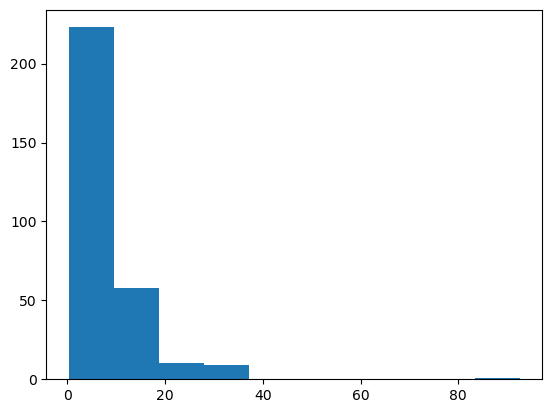

In [29]:
plt.hist(
    data["Present_Price"],
    kde=True
)

plt.show()

| Purpose                 | Visualization |
| ----------------------- | ------------- |
| Distribution            | Histogram     |
| Outliers                | Box Plot      |
| Category comparison     | Bar Chart     |
| Part-to-whole           | Pie Chart     |
| Two numerical variables | Scatter Plot  |
| Trend                   | Line Chart    |
| Correlation             | Heatmap       |
| Multiple features       | Pair Plot     |
| Category distribution   | Count Plot    |
